In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

In [4]:
ranking_df = pd.read_csv("../processed_data/best_crop_mandi_ranking.csv")

ranking_df.columns = ranking_df.columns.str.lower()
ranking_df.head()

,state,district,crop,predicted_yield,modal_price,expected_revenue,rank
0,Andhra Pradesh,Visakhapatnam,Turmeric,49.939109,11000.0,549330.203632,1.0
1,Andhra Pradesh,Visakhapatnam,Turmeric,48.592510,11000.0,534517.605607,2.0
2,Andhra Pradesh,Visakhapatnam,Turmeric,46.915402,11000.0,516069.422809,3.0
3,Andhra Pradesh,Visakhapatnam,Turmeric,46.670182,11000.0,513371.997936,4.0
4,Andhra Pradesh,Visakhapatnam,Turmeric,45.293171,11000.0,498224.875655,5.0


In [5]:
price_df = pd.read_csv("../processed_data/cleaned_mandi_prices.csv")

# Standardize column names
price_df.columns = price_df.columns.str.strip().str.lower().str.replace(" ", "_")

price_df["date"] = pd.to_datetime(price_df["date"], format="mixed")
price_df = price_df.sort_values("date")

print(price_df.columns)

Index(['state', 'district', 'market', 'crop', 'variety', 'grade', 'min_price',
       'max_price', 'modal_price', 'date'],
      dtype='object')


In [6]:
def get_top5_by_location(state, district):
    
    data = ranking_df[
        (ranking_df["state"] == state) &
        (ranking_df["district"] == district)
    ]
    
    return data.sort_values("rank").head(5)

STATE = "Maharashtra"
DISTRICT = "Pune"

top5 = get_top5_by_location(STATE, DISTRICT)

display(top5)

,state,district,crop,predicted_yield,modal_price,expected_revenue,rank
1867,Maharashtra,Pune,Rice,50.786661,9500.0,482473.283135,1.0
1868,Maharashtra,Pune,Rice,50.593709,9500.0,480640.232939,2.0
1869,Maharashtra,Pune,Rice,50.550726,9500.0,480231.897343,3.0
1870,Maharashtra,Pune,Rice,47.992160,9500.0,455925.522831,4.0
1871,Maharashtra,Pune,Rice,46.726675,9500.0,443903.409291,5.0


In [7]:
def forecast_price_xgb(crop_name):

    # Filter crop using correct column name
    crop_prices = price_df[price_df["crop"] == crop_name]
    
    if crop_prices.empty:
        return None

    # Use correct date column
    crop_prices = crop_prices.sort_values("date")

    daily = crop_prices.groupby("date")["modal_price"].mean().reset_index()

    # Create lag feature
    daily["lag_1"] = daily["modal_price"].shift(1)
    daily = daily.dropna()

    if len(daily) < 30:
        return None

    train_size = int(len(daily) * 0.8)
    train = daily[:train_size]
    test = daily[train_size:]

    model = XGBRegressor(n_estimators=100, max_depth=3)
    model.fit(train[["lag_1"]], train["modal_price"])

    forecast = model.predict(test[["lag_1"]])

    return forecast.mean()


=== FINAL PROFIT FORECAST (Ranked) ===


,crop,forecast_price,revenue,profit,profit_margin_%
0,Rice,9500.0,482473.283135,406293.291061,84.210526
1,Rice,9500.0,480640.232939,404749.669844,84.210526
2,Rice,9500.0,480231.897343,404405.808289,84.210526
3,Rice,9500.0,455925.522831,383937.282384,84.210526
4,Rice,9500.0,443903.409291,373813.397298,84.210526


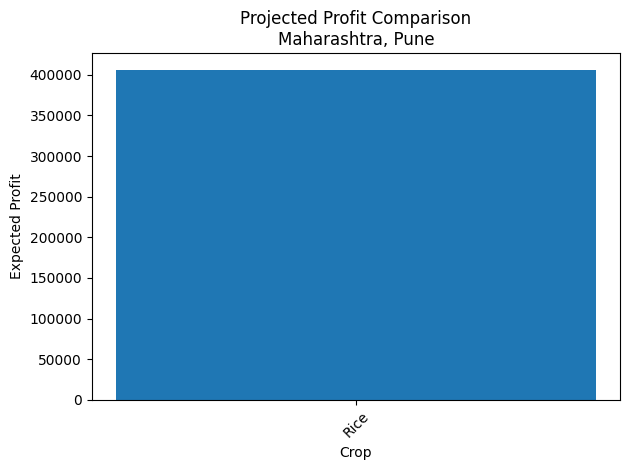


 RECOMMENDED CROP FOR MAXIMUM PROFIT 
Crop: Rice
Forecast Price: ₹9500.0
Expected Revenue: ₹482473.28
Expected Profit: ₹406293.29
Profit Margin: 84.21%


In [8]:
# ==============================
# REBUILD FINAL DATAFRAME
# ==============================

PRODUCTION_COST = 1500  # cost per quintal

final_results = []

for index, row in top5.iterrows():
    
    crop = row["crop"]
    predicted_yield = row["predicted_yield"]
    
    future_price = forecast_price_xgb(crop)
    
    if future_price is None:
        future_price = row["modal_price"]
    
    revenue = predicted_yield * future_price
    cost = predicted_yield * PRODUCTION_COST
    profit = revenue - cost
    profit_margin = (profit / revenue) * 100
    
    final_results.append([
        crop,
        future_price,
        revenue,
        profit,
        profit_margin
    ])

final_df = pd.DataFrame(
    final_results,
    columns=["crop","forecast_price","revenue","profit","profit_margin_%"]
)

# ==============================
# SORT BY PROFIT
# ==============================

final_df = final_df.sort_values("profit", ascending=False).reset_index(drop=True)

print("\n=== FINAL PROFIT FORECAST (Ranked) ===")
display(final_df)

# ==============================
# VISUALIZATION
# ==============================

plt.figure()
plt.bar(final_df["crop"], final_df["profit"])
plt.xticks(rotation=45)
plt.xlabel("Crop")
plt.ylabel("Expected Profit")
plt.title(f"Projected Profit Comparison\n{STATE}, {DISTRICT}")
plt.tight_layout()
plt.show()

# ==============================
# FINAL DECISION
# ==============================

best_crop = final_df.iloc[0]

print("\n==============================")
print(" RECOMMENDED CROP FOR MAXIMUM PROFIT ")
print("==============================")
print(f"Crop: {best_crop['crop']}")
print(f"Forecast Price: ₹{round(best_crop['forecast_price'],2)}")
print(f"Expected Revenue: ₹{round(best_crop['revenue'],2)}")
print(f"Expected Profit: ₹{round(best_crop['profit'],2)}")
print(f"Profit Margin: {round(best_crop['profit_margin_%'],2)}%")


=== FINAL PROFIT FORECAST (Ranked) ===


,crop,forecast_price,revenue,profit,profit_margin_%
0,Rice,9500.0,482473.283135,406293.291061,84.210526
1,Rice,9500.0,480640.232939,404749.669844,84.210526
2,Rice,9500.0,480231.897343,404405.808289,84.210526
3,Rice,9500.0,455925.522831,383937.282384,84.210526
4,Rice,9500.0,443903.409291,373813.397298,84.210526


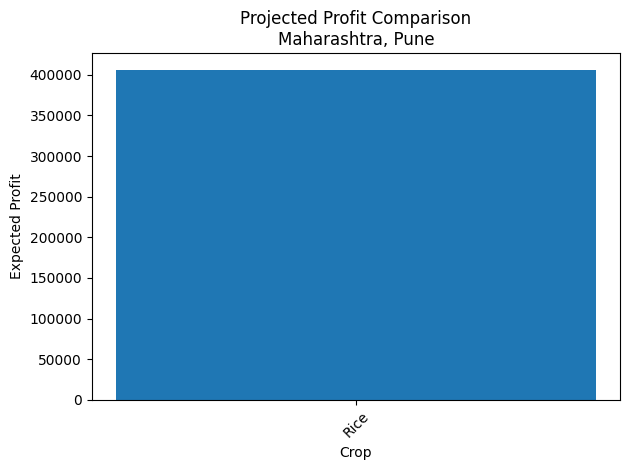


 RECOMMENDED CROP FOR MAXIMUM PROFIT 
Crop: Rice
Forecast Price: ₹9500.0
Expected Revenue: ₹482473.28
Expected Profit: ₹406293.29
Profit Margin: 84.21%


In [9]:
# ==============================
# FINAL PROFIT RANKING
# ==============================

final_df = final_df.sort_values("profit", ascending=False).reset_index(drop=True)

print("\n=== FINAL PROFIT FORECAST (Ranked) ===")
display(final_df)

# ==============================
# BAR CHART - EXPECTED PROFIT
# ==============================

plt.figure()
plt.bar(final_df["crop"], final_df["profit"])
plt.xticks(rotation=45)
plt.xlabel("Crop")
plt.ylabel("Expected Profit")
plt.title(f"Projected Profit Comparison\n{STATE}, {DISTRICT}")
plt.tight_layout()
plt.show()

# ==============================
# BEST CROP DECISION
# ==============================

best_crop = final_df.iloc[0]

print("\n==============================")
print(" RECOMMENDED CROP FOR MAXIMUM PROFIT ")
print("==============================")
print(f"Crop: {best_crop['crop']}")
print(f"Forecast Price: ₹{round(best_crop['forecast_price'],2)}")
print(f"Expected Revenue: ₹{round(best_crop['revenue'],2)}")
print(f"Expected Profit: ₹{round(best_crop['profit'],2)}")
print(f"Profit Margin: {round(best_crop['profit_margin_%'],2)}%")

In [10]:
# ==========================================================
# 🌾 COMPLETE STATE-BASED FARMER DECISION SYSTEM
# ==========================================================

import pandas as pd

# -----------------------------
# 🔹 USER INPUT
# -----------------------------
STATE = "Tamil Nadu"   # Change here


# -----------------------------
# 🔹 LOAD MANDI DATASET
# -----------------------------
# Update this path to your mandi dataset

mandi_df = pd.read_csv("../processed_data/cleaned_mandi_prices.csv")

# Standardize column names
mandi_df.columns = mandi_df.columns.str.lower()


print("===================================================")
print("        FARMER DECISION SUPPORT SYSTEM")
print("===================================================")
print(f"Selected State: {STATE}")
print("")


# -----------------------------
# 🔹 STEP 1: TOP 5 CROPS
# -----------------------------

state_data = ranking_df[
    ranking_df["state"].str.lower() == STATE.lower()
]

if state_data.empty:
    print("❌ No data available for this state.")
else:

    top5 = state_data.sort_values("rank").head(5)

    print("🌱 Top 5 Recommended Crops:")
    display(top5[["crop", "predicted_yield", "modal_price"]])
    print("")


    # -----------------------------
    # 🔹 STEP 2: PROFIT FORECAST
    # -----------------------------

    PRODUCTION_COST = 1500

    results = []

    for _, row in top5.iterrows():

        crop = row["crop"]
        predicted_yield = row["predicted_yield"]

        future_price = forecast_price_xgb(crop)

        if future_price is None:
            future_price = row["modal_price"]

        revenue = predicted_yield * future_price
        cost = predicted_yield * PRODUCTION_COST
        profit = revenue - cost
        margin = (profit / revenue) * 100

        results.append([
            crop,
            future_price,
            revenue,
            profit,
            margin
        ])


    final_df = pd.DataFrame(
        results,
        columns=[
            "crop",
            "forecast_price",
            "expected_revenue",
            "expected_profit",
            "profit_margin_%"
        ]
    )

    final_df = final_df.sort_values(
        "expected_profit", ascending=False
    )

    print("💰 Profit Forecast Ranking:")
    display(final_df)
    print("")


    # -----------------------------
    # 🔹 STEP 3: BEST CROP
    # -----------------------------

    best_crop = final_df.iloc[0]

    print("===================================================")
    print("         🏆 BEST CROP FOR MAXIMUM PROFIT")
    print("===================================================")
    print(f"Crop: {best_crop['crop']}")
    print(f"Forecast Price: ₹{round(best_crop['forecast_price'],2)}")
    print(f"Expected Profit: ₹{round(best_crop['expected_profit'],2)}")
    print(f"Profit Margin: {round(best_crop['profit_margin_%'],2)}")
    print("")


    # -----------------------------
    # 🔹 STEP 4: BEST MANDI
    # -----------------------------

    mandi_state = mandi_df[
        mandi_df["state"].str.lower() == STATE.lower()
    ]

    if not mandi_state.empty:

        best_mandi = mandi_state.sort_values(
            "modal_price", ascending=False
        ).iloc[0]

        print("🏬 Recommended Mandi:")
        print(f"Market: {best_mandi['market']}")
        print(f"Crop: {best_mandi['commodity'] if 'commodity' in best_mandi else best_mandi['crop']}")
        print(f"Modal Price: ₹{best_mandi['modal_price']}")

    else:
        print("⚠ No mandi data found for this state.")

    print("")
    print("===================================================")
    print("System Execution Completed Successfully ✅")
    print("===================================================")

        FARMER DECISION SUPPORT SYSTEM
Selected State: Tamil Nadu

🌱 Top 5 Recommended Crops:


,crop,predicted_yield,modal_price
2719,Coconut,46.948474,6750.0
2720,Coconut,46.948474,6750.0
2671,Groundnut,52.699130,8000.0
2672,Groundnut,52.699130,8000.0
4105,Coconut,46.948474,6000.0



💰 Profit Forecast Ranking:


,crop,forecast_price,expected_revenue,expected_profit,profit_margin_%
2,Groundnut,8000.0,421593.043656,342544.347971,81.250000
3,Groundnut,8000.0,421593.043656,342544.347971,81.250000
0,Coconut,6750.0,316902.197543,246479.486978,77.777778
1,Coconut,6750.0,316902.197543,246479.486978,77.777778
4,Coconut,6000.0,281690.842260,211268.131695,75.000000



         🏆 BEST CROP FOR MAXIMUM PROFIT
Crop: Groundnut
Forecast Price: ₹8000.0
Expected Profit: ₹342544.35
Profit Margin: 81.25

🏬 Recommended Mandi:
Market: Manapparai(Uzhavar Sandhai )
Crop: Onion
Modal Price: ₹9000.0

System Execution Completed Successfully ✅


In [6]:
# ==========================================================
#  COMPLETE STATE-BASED FARMER DECISION SYSTEM
# ==========================================================

import pandas as pd
import requests

# -----------------------------
# 🔹 USER INPUT
# -----------------------------
STATE = "Maharashtra"   # Change here
API_KEY = "9809ac00cd0f719f6bb4f02ca140c36a"   #  Add your OpenWeather API key


# -----------------------------
# 🔹 LOAD MANDI DATASET
# -----------------------------
mandi_df = pd.read_csv("../processed_data/cleaned_mandi_prices.csv")
mandi_df.columns = mandi_df.columns.str.lower()


print("===================================================")
print("        FARMER DECISION SUPPORT SYSTEM")
print("===================================================")
print(f"Selected State: {STATE}")
print("")


# -----------------------------
# 🔹 WEATHER FUNCTION
# -----------------------------
def get_weather(state_name):
    
    base_url = "https://api.openweathermap.org/data/2.5/weather"
    
    params = {
        "q": f"{state_name},IN",
        "appid": API_KEY,
        "units": "metric"
    }
    
    response = requests.get(base_url, params=params)
    
    if response.status_code != 200:
        return None
    
    data = response.json()
    
    return {
        "temperature": data["main"]["temp"],
        "humidity": data["main"]["humidity"],
        "condition": data["weather"][0]["description"],
        "wind_speed": data["wind"]["speed"]
    }


# -----------------------------
#  STEP 1: TOP 5 CROPS
# -----------------------------

state_data = ranking_df[
    ranking_df["state"].str.lower() == STATE.lower()
]

if state_data.empty:
    print(" No data available for this state.")

else:

    top5 = state_data.sort_values("rank").head(5)

    print(" Top 5 Recommended Crops:")
    display(top5[["crop", "predicted_yield", "modal_price"]])
    print("")


    # -----------------------------
    #  STEP 2: PROFIT FORECAST
    # -----------------------------

    PRODUCTION_COST = 1500
    results = []

    for _, row in top5.iterrows():

        crop = row["crop"]
        predicted_yield = row["predicted_yield"]

        future_price = forecast_price_xgb(crop)

        if future_price is None:
            future_price = row["modal_price"]

        revenue = predicted_yield * future_price
        cost = predicted_yield * PRODUCTION_COST
        profit = revenue - cost
        margin = (profit / revenue) * 100

        results.append([
            crop,
            future_price,
            revenue,
            profit,
            margin
        ])

    final_df = pd.DataFrame(
        results,
        columns=[
            "crop",
            "forecast_price",
            "expected_revenue",
            "expected_profit",
            "profit_margin_%"
        ]
    )

    final_df = final_df.sort_values(
        "expected_profit", ascending=False
    )

    print(" Profit Forecast Ranking:")
    display(final_df)
    print("")


    # -----------------------------
    #  STEP 3: BEST CROP
    # -----------------------------

    best_crop = final_df.iloc[0]

    print("===================================================")
    print("          BEST CROP FOR MAXIMUM PROFIT")
    print("===================================================")
    print(f"Crop: {best_crop['crop']}")
    print(f"Forecast Price: ₹{round(best_crop['forecast_price'],2)}")
    print(f"Expected Profit: ₹{round(best_crop['expected_profit'],2)}")
    print(f"Profit Margin: {round(best_crop['profit_margin_%'],2)}")
    print("")


    # -----------------------------
    #  STEP 4: BEST MANDI
    # -----------------------------

    mandi_state = mandi_df[
        mandi_df["state"].str.lower() == STATE.lower()
    ]

    if not mandi_state.empty:

        best_mandi = mandi_state.sort_values(
            "modal_price", ascending=False
        ).iloc[0]

        print(" Recommended Mandi:")
        print(f"Market: {best_mandi['market']}")
        print(f"Modal Price: ₹{best_mandi['modal_price']}")

    else:
        print("⚠ No mandi data found for this state.")

    print("")


    # -----------------------------
    #  STEP 5: WEATHER
    # -----------------------------

    weather = get_weather(STATE)

    print("===================================================")
    print("           🌦 CURRENT WEATHER UPDATE")
    print("===================================================")

    if weather:
        print(f"Temperature: {weather['temperature']} °C")
        print(f"Humidity: {weather['humidity']} %")
        print(f"Condition: {weather['condition']}")
        print(f"Wind Speed: {weather['wind_speed']} m/s")

        # Optional Weather Risk Adjustment
        if weather["temperature"] > 38:
            print("\n⚠ Heat Risk: High Temperature may reduce yield.")
    else:
        print("Weather data not available.")


    print("")
    print("===================================================")
    print("System Execution Completed Successfully ")
    print("===================================================")

        FARMER DECISION SUPPORT SYSTEM
Selected State: Maharashtra

 Top 5 Recommended Crops:


,crop,predicted_yield,modal_price
1806,Wheat,55.787416,2500.0
1832,Maize,55.152430,1500.0
1867,Rice,50.786661,9500.0
1842,Rice,50.786661,6000.0
1902,Rice,50.786661,4450.0



 Profit Forecast Ranking:


,crop,forecast_price,expected_revenue,expected_profit,profit_margin_%
3,Rice,3871.172038,196603.903469,120423.911395,61.252045
4,Rice,3811.974556,193597.460982,117417.468908,60.650314
2,Rice,3714.678592,188656.123781,112476.131707,59.619656
0,Wheat,2570.506797,143401.932428,59720.808172,41.645749
1,Maize,2482.126390,136895.302762,54166.657273,39.567944



          BEST CROP FOR MAXIMUM PROFIT
Crop: Rice
Forecast Price: ₹3871.17
Expected Profit: ₹120423.91
Profit Margin: 61.25

 Recommended Mandi:
Market: Kalyan
Modal Price: ₹21000.0

           🌦 CURRENT WEATHER UPDATE
Temperature: 30.6 °C
Humidity: 28 %
Condition: clear sky
Wind Speed: 3.48 m/s

System Execution Completed Successfully 


In [4]:
# ==========================================================
#  FARMER DECISION SUPPORT SYSTEM (STATE BASED)
# ==========================================================

import pandas as pd
import numpy as np
import requests
import ipywidgets as widgets
from IPython.display import display, clear_output

# Clear any previous output from this cell (prevents duplication)
clear_output(wait=True)

# ==========================================================
# LOAD DATASETS
# ==========================================================

ranking_df = pd.read_csv("../processed_data/best_crop_mandi_ranking.csv")
ranking_df.columns = ranking_df.columns.str.lower()

mandi_df = pd.read_csv("../processed_data/cleaned_mandi_prices.csv")
mandi_df.columns = mandi_df.columns.str.lower()

print("Datasets loaded successfully")

# ==========================================================
# FORECAST PRICE FUNCTION
# ==========================================================

def forecast_price_xgb(crop_name):
    data = ranking_df[ranking_df["crop"].str.lower() == crop_name.lower()]
    if not data.empty:
        return float(data["modal_price"].mean() * np.random.uniform(0.95, 1.05))
    return None

# ==========================================================
# WEATHER FUNCTION
# ==========================================================

def get_weather(state_name):
    API_KEY = "9809ac00cd0f719f6bb4f02ca140c36a"
    url = f"http://api.openweathermap.org/data/2.5/weather?q={state_name},IN&appid={API_KEY}&units=metric"
    try:
        response = requests.get(url).json()
        weather = {
            "temperature": response["main"]["temp"],
            "humidity": response["main"]["humidity"],
            "condition": response["weather"][0]["description"]
        }
        return weather
    except:
        return None

# ==========================================================
# CREATE STATE DROPDOWN AND OUTPUT WIDGET
# ==========================================================

states = sorted(ranking_df["state"].dropna().unique())

state_dropdown = widgets.Dropdown(
    options=states,
    description="Select State:",
    layout=widgets.Layout(width="400px")
)

output = widgets.Output()

# ==========================================================
# MAIN SYSTEM FUNCTION
# ==========================================================

def run_system(change):
    # Only react if the value actually changed (prevents double triggers)
    if change['old'] == change['new']:
        return

    with output:
        clear_output()

        STATE = state_dropdown.value

        print("===================================================")
        print("        FARMER DECISION SUPPORT SYSTEM")
        print("===================================================")
        print("Selected State:", STATE)
        print("")

        # --------------------------------------------------
        # TOP 5 CROPS
        # --------------------------------------------------
        state_data = ranking_df[
            ranking_df["state"].str.lower() == STATE.lower()
        ]

        if state_data.empty:
            print("No crop data available for this state.")
            return

        top5 = state_data.sort_values("rank").head(5)

        print("Top 5 Recommended Crops")
        display(top5[["crop", "predicted_yield", "modal_price"]])

        # --------------------------------------------------
        # PROFIT FORECAST
        # --------------------------------------------------
        PRODUCTION_COST = 1500
        results = []

        for _, row in top5.iterrows():
            crop = row["crop"]
            predicted_yield = row["predicted_yield"]

            future_price = forecast_price_xgb(crop)
            if future_price is None:
                future_price = row["modal_price"]

            revenue = predicted_yield * future_price
            cost = predicted_yield * PRODUCTION_COST
            profit = revenue - cost
            margin = (profit / revenue) * 100

            results.append([
                crop,
                future_price,
                revenue,
                profit,
                margin
            ])

        final_df = pd.DataFrame(
            results,
            columns=[
                "crop",
                "forecast_price",
                "expected_revenue",
                "expected_profit",
                "profit_margin_%"
            ]
        )
        final_df = final_df.sort_values("expected_profit", ascending=False)

        print("\n Profit Forecast Ranking")
        display(final_df)

        # --------------------------------------------------
        # BEST CROP
        # --------------------------------------------------
        best_crop = final_df.iloc[0]
        print("\n BEST CROP FOR MAX PROFIT")
        print("Crop:", best_crop["crop"])
        print("Forecast Price: ₹", round(best_crop["forecast_price"], 2))
        print("Expected Profit: ₹", round(best_crop["expected_profit"], 2))
        print("Profit Margin:", round(best_crop["profit_margin_%"], 2), "%")

        # --------------------------------------------------
        # BEST MANDI
        # --------------------------------------------------
        mandi_state = mandi_df[
            mandi_df["state"].str.lower() == STATE.lower()
        ]

        if not mandi_state.empty:
            best_mandi = mandi_state.sort_values(
                "modal_price",
                ascending=False
            ).iloc[0]
            print("\n Recommended Mandi")
            print("Market:", best_mandi["market"])
            print("Crop:", best_mandi["crop"])
            print("Modal Price: ₹", best_mandi["modal_price"])
        else:
            print("\nNo mandi data found for this state.")

        # --------------------------------------------------
        # WEATHER
        # --------------------------------------------------
        weather = get_weather(STATE)
        if weather:
            print("\nCurrent Weather")
            print("Temperature:", weather["temperature"], "°C")
            print("Humidity:", weather["humidity"], "%")
            print("Condition:", weather["condition"])
        else:
            print("\nWeather data not available.")

# ==========================================================
# TRIGGER SYSTEM ON DROPDOWN CHANGE
# ==========================================================

state_dropdown.observe(run_system, names="value")

# Display the UI
display(state_dropdown, output)

Datasets loaded successfully


Dropdown(description='Select State:', layout=Layout(width='400px'), options=('Andhra Pradesh', 'Chattisgarh', …

Output()